Dimensionality d = 200
Train / test sizes: 80 / 5000
=== Baseline (no adversary) ===
Train loss: 2.1199e-13
Test  loss: 5.3670e+00

=== Algorithm 1: particle ascent (min–max) ===
Train loss on original inputs:   1.0138e+01
Train loss on adversarial inputs: 1.2054e+01
Test  loss (original inputs):     9.5667e+00
Final regularized objective J:    1.0432e+01
Final grad_theta norm:            8.9224e-03
Final grad_adv   norm:            8.9233e-02
Distance beta_alg1 to beta*:      4.3645e+00

=== Algorithm 2: ICNN-based transport (min–max) ===
Train loss (original inputs):          7.0968e+00
Test  loss  (original inputs):         8.4986e+00
Train loss with learned transport:     1.1592e+01
Test  loss  with learned transport:    6.9379e+00
Final regularized objective J:         9.0160e+00
Final grad_theta norm:                6.0971e-02
Final grad_omega norm:                5.7371e-01
Distance theta (Alg2) to beta*:        4.1148e+00



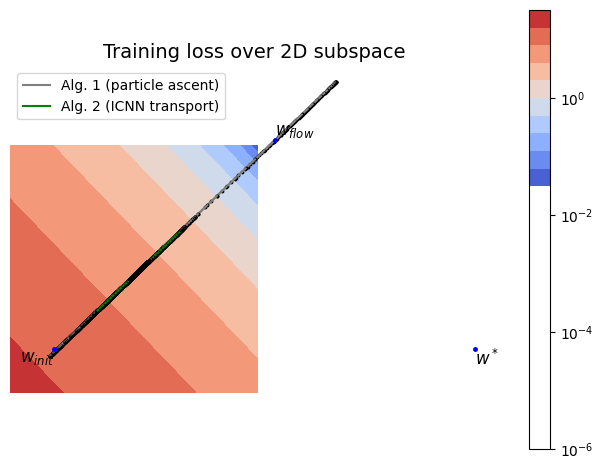

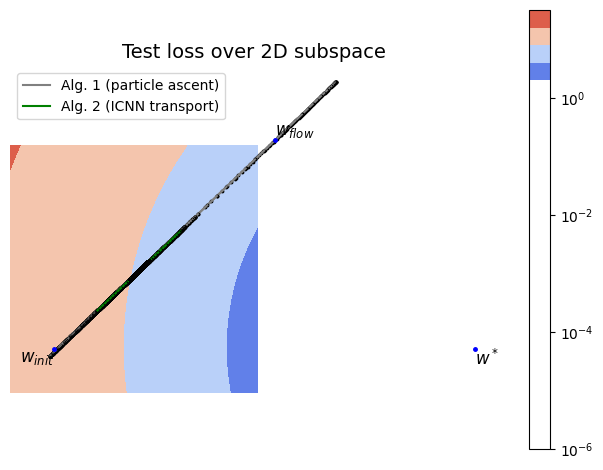

In [2]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from matplotlib import ticker

# ============================================================
#  Basic setup
# ============================================================

def reset_seeds(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
reset_seeds(0)

# ============================================================
#  Synthetic diagonal linear regression data
#  (teacher–student setting as in Andriushchenko et al.)
# ============================================================

def generate_diag_data(n_train=80, n_test=5000, d=200, r=20, noise_std=0.0):
    """
    Teacher–student diagonal linear model:
      x ~ N(0, I_d)
      y = <beta_star, x> + eps
    with r-sparse beta_star.
    """
    beta_star = torch.zeros(d)
    support = torch.randperm(d)[:r]
    beta_star[support] = torch.randn(r)
    # Normalize so ||beta_star|| ~ sqrt(r)
    beta_star = beta_star / beta_star.norm() * math.sqrt(r)

    X_train = torch.randn(n_train, d)
    X_test = torch.randn(n_test, d)

    y_train = X_train @ beta_star
    y_test = X_test @ beta_star

    if noise_std > 0.0:
        y_train = y_train + noise_std * torch.randn_like(y_train)
        y_test = y_test + noise_std * torch.randn_like(y_test)

    return X_train, y_train, X_test, y_test, beta_star


# (Optional) dataset class – not actually used in the current script
class TensorDataset1D(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.size(0)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ============================================================
#  Linear model (decision-maker)
# ============================================================

class LinearRegressor(nn.Module):
    """
    Simple linear predictor h_theta(x) = <theta, x>.
    """
    def __init__(self, d):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(d))

    def forward(self, x):
        return x @ self.theta

    def beta(self):
        # Return current parameter on CPU for analysis/plotting
        return self.theta.detach().cpu().clone()


# ============================================================
#  ICNN components (Input Convex Neural Network)
# ============================================================

def icnn_principled_moments(fan_in: int):
    """Match icnn_principled_moments from MNIST ICNN code for positive weights."""
    if fan_in <= 0:
        raise ValueError(f"ICNN fan-in must be positive; got {fan_in}.")
    denom_offset = 6.0 * (math.pi - 1.0)
    denom_slope = 3.0 * math.sqrt(3.0) + 2.0 * math.pi - 6.0
    denom = denom_offset + (fan_in - 1.0) * denom_slope
    mu_w = math.sqrt((6.0 * math.pi) / (fan_in * denom))
    sigma_w2 = 1.0 / float(fan_in)
    mu_b = math.sqrt((3.0 * fan_in) / denom)
    mu_w_sq = mu_w * mu_w
    log_var_plus_mean_sq = math.log(sigma_w2 + mu_w_sq)
    log_mean_sq = math.log(mu_w_sq)
    tilde_mu = log_mean_sq - 0.5 * log_var_plus_mean_sq
    tilde_sigma2 = max(log_var_plus_mean_sq - log_mean_sq, 1e-12)
    tilde_sigma = math.sqrt(tilde_sigma2)
    return mu_w, sigma_w2, mu_b, tilde_mu, tilde_sigma


class NonNegativeLinear(nn.Module):
    """Linear map with strictly non-negative weights via exp/softplus."""
    def __init__(self, in_features, out_features, bias=True, init_mode="principled"):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.use_bias = bias
        self.init_mode = init_mode.lower()
        if self.init_mode not in {"principled", "xavier"}:
            raise ValueError(f"Unsupported init_mode '{init_mode}' for NonNegativeLinear.")
        self.parametrization = "exp" if self.init_mode == "principled" else "softplus"

        self.weight_param = nn.Parameter(torch.empty(in_features, out_features))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            self.register_parameter("bias", None)

        self.reset_parameters()

    def reset_parameters(self):
        if self.init_mode == "principled":
            mu_w, sigma_w2, mu_b, tilde_mu, tilde_sigma = icnn_principled_moments(self.in_features)
            with torch.no_grad():
                if tilde_sigma == 0.0:
                    self.weight_param.fill_(tilde_mu)
                else:
                    self.weight_param.normal_(mean=tilde_mu, std=tilde_sigma)
                if self.bias is not None:
                    self.bias.fill_(mu_b)
        else:
            nn.init.xavier_uniform_(self.weight_param)
            if self.bias is not None:
                nn.init.zeros_(self.bias)

    def forward(self, x):
        if self.parametrization == "exp":
            weight = torch.exp(self.weight_param)
        else:
            weight = F.softplus(self.weight_param)
        y = x.matmul(weight)
        if self.bias is not None:
            y = y + self.bias
        return y


class InputConvexPotential(nn.Module):
    """
    Dense ICNN potential φ(z):
    - Non-negative hidden couplings with principled init
    - Softplus activation with adjustable beta
    - Quadratic strong-convexity term 0.5 * m * ||z||^2
    """
    def __init__(
        self,
        input_dim=2,
        hidden_sizes=(64, 64, 64),
        activation="softplus",
        strong_convexity=1.0,
        nonneg_init="principled",
        softplus_beta=20.0,
    ):
        super().__init__()
        if len(hidden_sizes) == 0:
            raise ValueError("ICNN requires at least one hidden layer.")
        self.input_dim = input_dim
        self.hidden_sizes = hidden_sizes
        self.activation = activation
        self.strong_convexity = strong_convexity
        self.softplus_beta = softplus_beta

        self.z_linears = nn.ModuleList()
        self.h_linears = nn.ModuleList()
        for i, width in enumerate(hidden_sizes):
            self.z_linears.append(nn.Linear(input_dim, width, bias=True))
            if i == 0:
                self.h_linears.append(None)
            else:
                self.h_linears.append(
                    NonNegativeLinear(
                        hidden_sizes[i - 1],
                        width,
                        bias=False,
                        init_mode=nonneg_init,
                    )
                )

        self.hidden_output = NonNegativeLinear(
            hidden_sizes[-1],
            1,
            bias=True,
            init_mode=nonneg_init,
        )
        self.input_skip = nn.Linear(input_dim, 1, bias=True)

    def _activation(self):
        act_name = self.activation.lower()
        if act_name == "relu":
            return F.relu
        if act_name == "softplus":
            beta = float(self.softplus_beta)
            return lambda u: F.softplus(beta * u) / beta
        raise ValueError(f"Unsupported ICNN activation '{self.activation}'.")

    def forward(self, x):
        z = x.view(x.size(0), -1)
        act = self._activation()

        h = act(self.z_linears[0](z))
        for k in range(1, len(self.z_linears)):
            z_term = self.z_linears[k](z)
            h_term = self.h_linears[k](h) if self.h_linears[k] is not None else 0.0
            h = act(z_term + h_term)

        quadratic = 0.5 * self.strong_convexity * (z ** 2).sum(dim=1, keepdim=True)
        out = quadratic + self.input_skip(z) + self.hidden_output(h)
        return out.squeeze(-1)


# Alias for convenience
ICNN = InputConvexPotential


def icnn_transport(icnn, x, create_graph=False):
    """
    Compute T(x) = ∇_x φ(x) via autograd.
    Returns T(x) with the same shape as x.
    IMPORTANT: do not call this inside torch.no_grad().
    """
    x_ = x.clone().detach().requires_grad_(True)
    phi = icnn(x_)
    grads = torch.autograd.grad(
        outputs=phi.sum(),
        inputs=x_,
        create_graph=create_graph
    )[0]
    return grads.view_as(x)


# ============================================================
#  Losses and objectives
# ============================================================

def mse_from_beta(beta, X, y):
    """
    1/2 * E[ (X beta - y)^2 ]
    """
    pred = X @ beta
    return 0.5 * ((pred - y) ** 2).mean().item()


def dro_objective_alg1(theta, X_adv, X_orig, y, lam):
    """
    J(θ, {x_adv}) = E[ 1/2 (θ^T x_adv - y)^2 - λ ||x_adv - x||^2 ].
    """
    X_advd = X_adv
    Xd = X_orig
    yd = y
    with torch.no_grad():
        pred = X_advd @ theta
        se = 0.5 * (pred - yd) ** 2
        reg = (X_advd - Xd).pow(2).sum(dim=1)
        J = se.mean() - lam * reg.mean()
    return J.item()


def dro_objective_alg2(theta, icnn, X, y, lam):
    """
    J(θ, ω) = E[ 1/2 (θ^T T_ω(x) - y)^2 - λ ||T_ω(x) - x||^2 ].
    """
    Xd = X.to(device)
    yd = y.to(device)
    theta = theta.to(device)
    T_x = icnn_transport(icnn, Xd, create_graph=False)
    pred = T_x @ theta
    se = 0.5 * (pred - yd) ** 2
    reg = (T_x - Xd).pow(2).sum(dim=1)
    J = se.mean() - lam * reg.mean()
    return J.item()


# ============================================================
#  Helpers
# ============================================================

def grad_norm_parameters(model):
    sq = 0.0
    for p in model.parameters():
        if p.grad is not None:
            sq += p.grad.pow(2).sum().item()
    return math.sqrt(sq)


# ============================================================
#  Baseline training: standard least-squares with GD
# ============================================================

def train_baseline(model, X, y, num_iters=5000, lr=0.05):
    """
    Full-batch gradient descent on 1/2 * MSE without adversary.
    Store beta trajectory for 2D visualization.
    """
    model.to(device)
    Xd = X.to(device)
    yd = y.to(device)

    opt = torch.optim.SGD(model.parameters(), lr=lr)

    beta_traj = []

    for it in range(num_iters):
        pred = model(Xd)
        loss = 0.5 * (pred - yd).pow(2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        beta_traj.append(model.beta())

    return model, beta_traj


# ============================================================
#  Algorithm 1: particle ascent (min–max over free particles)
# ============================================================

def train_algorithm1(model,
                     X,
                     y,
                     lam=0.5,
                     inner_steps=5,
                     inner_lr=0.1,
                     outer_lr=0.05,
                     num_iters=2000):
    """
    Full-batch Algorithm 1:
      min_theta max_{x_adv} E[ 1/2 (θ^T x_adv - y)^2 - λ ||x_adv - x||^2 ].

    Inner loop: gradient ascent on x_adv.
    Outer loop: gradient descent on θ using MSE on current adversarial points.
    """
    d = X.size(1)
    model.to(device)
    Xd = X.to(device)
    yd = y.to(device)

    # Persistent adversarial state
    X_adv = Xd.clone().detach()

    opt_theta = torch.optim.SGD(model.parameters(), lr=outer_lr)

    logs = {
        "J": [],
        "F": [],
        "grad_theta": [],
        "grad_adv": [],
        "beta": [],
    }

    for it in range(num_iters):
        # ----- inner maximization over X_adv -----
        X_adv_var = X_adv.clone().detach().requires_grad_(True)
        for s in range(inner_steps):
            pred = X_adv_var @ model.theta
            se = 0.5 * (pred - yd) ** 2
            reg = (X_adv_var - Xd).pow(2).sum(dim=1)
            J = se.mean() - lam * reg.mean()
            grad_x = torch.autograd.grad(J, X_adv_var)[0]
            X_adv_var = X_adv_var + inner_lr * grad_x
            X_adv_var = X_adv_var.detach().requires_grad_(True)
        X_adv = X_adv_var.detach()

        # ----- diagnostics at (theta, X_adv) -----
        X_adv_diag = X_adv.clone().detach().requires_grad_(True)
        pred_diag = X_adv_diag @ model.theta
        se_diag = 0.5 * (pred_diag - yd) ** 2
        reg_diag = (X_adv_diag - Xd).pow(2).sum(dim=1)
        J_diag = se_diag.mean() - lam * reg_diag.mean()
        F_diag = se_diag.mean()

        model.zero_grad()
        if X_adv_diag.grad is not None:
            X_adv_diag.grad.zero_()
        J_diag.backward()
        grad_theta = grad_norm_parameters(model)
        grad_adv = X_adv_diag.grad.view(-1).norm().item()
        model.zero_grad()

        logs["J"].append(J_diag.item())
        logs["F"].append(F_diag.item())
        logs["grad_theta"].append(grad_theta)
        logs["grad_adv"].append(grad_adv)
        logs["beta"].append(model.beta())

        # ----- outer minimization over theta (θ) using current X_adv -----
        pred_outer = X_adv.detach() @ model.theta
        mse_outer = 0.5 * (pred_outer - yd) ** 2
        F_outer = mse_outer.mean()

        opt_theta.zero_grad()
        F_outer.backward()
        opt_theta.step()

    return model, X_adv.detach().cpu(), logs


# ============================================================
#  Algorithm 2: ICNN-based transport (min–max over ω)
# ============================================================

def train_algorithm2(model,
                     icnn,
                     X,
                     y,
                     lam=0.5,
                     inner_steps=5,
                     lr_theta=0.01,
                     lr_omega=0.01,
                     num_iters=2000,
                     grad_clip_theta=5.0,
                     grad_clip_omega=5.0):
    """
    Full-batch Algorithm 2:
      min_theta max_ω E[ 1/2 (θ^T T_ω(x) - y)^2 - λ ||T_ω(x) - x||^2 ],
      with T_ω(x) = ∇_x φ(x; ω).

    Inner loop: gradient ascent on ω (ICNN) to increase J(θ, ω).
    Outer loop: gradient descent on θ using the MSE on the transported inputs T_ω(x),
    keeping ω fixed.
    """
    model.to(device)
    icnn.to(device)
    Xd = X.to(device)
    yd = y.to(device)

    opt_theta = torch.optim.SGD(model.parameters(), lr=lr_theta)
    opt_omega = torch.optim.SGD(icnn.parameters(), lr=lr_omega)

    logs = {
        "J": [],
        "F": [],
        "grad_theta": [],
        "grad_omega": [],
        "beta": [],
    }

    for it in range(num_iters):
        # ---------- inner loop: maximize J over ω ----------
        # θ is treated as constant in the inner loop
        for p in model.parameters():
            p.requires_grad_(False)

        omega_grad_norm = 0.0

        for _ in range(inner_steps):
            opt_omega.zero_grad()

            # T_ω(x) with gradient w.r.t. ω
            T_x = icnn_transport(icnn, Xd, create_graph=True)

            # detach θ so no gradient flows into θ
            theta_vec = model.theta.detach()

            pred_adv = T_x @ theta_vec
            adv_loss = 0.5 * ((pred_adv - yd) ** 2).mean()
            reg = ((T_x - Xd) ** 2).sum(dim=1).mean()

            J = adv_loss - lam * reg            # inner objective
            loss_omega = -J                     # maximize J via gradient descent

            loss_omega.backward()

            if grad_clip_omega is not None:
                torch.nn.utils.clip_grad_norm_(icnn.parameters(), grad_clip_omega)

            omega_grad_norm = grad_norm_parameters(icnn)

            opt_omega.step()

        for p in model.parameters():
            p.requires_grad_(True)

        # ---------- diagnostics at (θ, ω) ----------
        T_x_diag = icnn_transport(icnn, Xd, create_graph=True)
        pred_diag = T_x_diag @ model.theta
        se_diag = 0.5 * (pred_diag - yd) ** 2
        reg_diag = (T_x_diag - Xd).pow(2).sum(dim=1)
        J_diag = se_diag.mean() - lam * reg_diag.mean()
        F_diag = se_diag.mean()

        opt_theta.zero_grad()
        opt_omega.zero_grad()
        J_diag.backward()
        grad_theta = grad_norm_parameters(model)
        grad_omega_diag = grad_norm_parameters(icnn)
        opt_theta.zero_grad()
        opt_omega.zero_grad()

        # use omega_grad_norm from last inner step for logging (more relevant)
        logs["J"].append(J_diag.item())
        logs["F"].append(F_diag.item())
        logs["grad_theta"].append(grad_theta)
        logs["grad_omega"].append(omega_grad_norm)
        logs["beta"].append(model.beta())

        # ---------- outer loop: descend in θ with ω fixed ----------
        opt_theta.zero_grad()

        # T_ω(x) as fixed features: cut gradient to ω
        T_x_outer = icnn_transport(icnn, Xd, create_graph=False).detach()
        pred_outer = T_x_outer @ model.theta
        train_loss = 0.5 * ((pred_outer - yd) ** 2).mean()

        train_loss.backward()
        if grad_clip_theta is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_theta)
        opt_theta.step()

    return model, icnn, logs


# ============================================================
#  2D loss-surface visualization (Andriushchenko-style)
# ============================================================

def project_point(beta, beta0, v1, v2):
    """
    Orthogonal projection of (beta - beta0) onto basis {v1, v2},
    returning coordinates (alpha, beta_coord).
    """
    diff = beta - beta0
    a = (diff @ v1) / (v1 @ v1)
    b = (diff @ v2) / (v2 @ v2)
    return a.item(), b.item()


def plot_loss_surface_and_trajectories(X_train,
                                       y_train,
                                       X_test,
                                       y_test,
                                       beta_init,
                                       beta_star,
                                       beta_flow,
                                       traj_alg1,
                                       traj_alg2,
                                       n_pts=100,
                                       coef_min=-0.5,
                                       coef_max=2.3,
                                       log_base=2.0):
    """
    Emulates Fig. 3 from Andriushchenko et al.:
    - construct 2D subspace spanned by beta_star - beta0 and beta_flow - beta0;
    - plot training/test loss contours over this plane for linear predictors beta;
    - overlay trajectories of Algorithm 1 and Algorithm 2 in this plane.
    """
    d = beta_init.numel()
    beta0 = 0.1 * torch.ones(d)

    # First direction: from beta0 to beta_star
    v1 = beta_star - beta0
    v1 = v1 / v1.norm()

    # Second direction: component of beta_flow - beta0 orthogonal to v1
    diff_flow = beta_flow - beta0
    proj_coef = (diff_flow @ v1)
    v2 = diff_flow - proj_coef * v1
    v2 = v2 / v2.norm()

    alphas = np.linspace(coef_min, coef_max, n_pts)
    betas = np.linspace(coef_min, coef_max, n_pts)
    train_loss = np.zeros((n_pts, n_pts))
    test_loss = np.zeros((n_pts, n_pts))

    for i, alpha in enumerate(alphas):
        for j, beta_c in enumerate(betas):
            beta_vec = beta0 + alpha * v1 + beta_c * v2
            # swap indices so that alphas correspond to x-axis, betas to y-axis
            train_loss[j, i] = mse_from_beta(beta_vec, X_train, y_train)
            test_loss[j, i] = mse_from_beta(beta_vec, X_test, y_test)

    max_allowed = 100.0
    train_loss = np.clip(train_loss, 1e-8, max_allowed)
    test_loss = np.clip(test_loss, 1e-8, max_allowed)

    def contour_plot(loss_grid, title, trajs, labels):
        fig = plt.figure()
        plt.contourf(
            alphas,
            betas,
            loss_grid,
            cmap="coolwarm",
            locator=ticker.LogLocator(base=log_base, numticks=30),
        )
        cbar = plt.colorbar()
        cbar.set_ticks([10**-6, 10**-4, 10**-2, 10**0])

        colors = ["gray", "green"]

        for k, (traj, label) in enumerate(zip(trajs, labels)):
            if traj is None or len(traj) == 0:
                continue
            al_prev, be_prev = project_point(traj[0], beta0, v1, v2)
            for t, beta_vec in enumerate(traj):
                al, be = project_point(beta_vec, beta0, v1, v2)
                plt.plot(
                    (al_prev, al),
                    (be_prev, be),
                    color=colors[k],
                    label=label if t == 0 else "",
                )
                plt.plot(al, be, marker=".", markersize=3.5, color="black")
                al_prev, be_prev = al, be

        # Mark initialization
        plt.plot(0, 0, marker=".", markersize=5.0, color="blue")
        plt.annotate("$w_{init}$", (0, 0), fontsize=12, ha="right", va="top")

        # Mark teacher
        alpha_star, beta_star_coord = project_point(beta_star, beta0, v1, v2)
        plt.plot(alpha_star, beta_star_coord, marker=".", markersize=5.0, color="blue")
        plt.annotate("$w^*$", (alpha_star, beta_star_coord),
                     fontsize=12, ha="left", va="top")

        # Mark gradient-flow solution
        alpha_flow, beta_flow_coord = project_point(beta_flow, beta0, v1, v2)
        plt.plot(alpha_flow, beta_flow_coord, marker=".", markersize=5.0, color="blue")
        plt.annotate("$w_{flow}$", (alpha_flow, beta_flow_coord),
                     fontsize=12, ha="left", va="bottom")

        plt.gca().set_aspect("equal")
        plt.axis("off")
        plt.title(title, fontsize=14)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Training loss surface
    contour_plot(
        train_loss,
        title="Training loss over 2D subspace",
        trajs=[traj_alg1, traj_alg2],
        labels=["Alg. 1 (particle ascent)", "Alg. 2 (ICNN transport)"],
    )

    # Test loss surface
    contour_plot(
        test_loss,
        title="Test loss over 2D subspace",
        trajs=[traj_alg1, traj_alg2],
        labels=["Alg. 1 (particle ascent)", "Alg. 2 (ICNN transport)"],
    )


# ============================================================
#  Main experiment
# ============================================================

def main():
    # Generate data in the diagonal linear setting
    X_train, y_train, X_test, y_test, beta_star = generate_diag_data()
    print("Dimensionality d =", X_train.size(1))
    print("Train / test sizes:", X_train.size(0), "/", X_test.size(0))

    # ---------- Baseline GD (no adversary) ----------
    reset_seeds(1)
    base_model = LinearRegressor(d=X_train.size(1))
    base_model, beta_traj_base = train_baseline(
        base_model, X_train, y_train, num_iters=5000, lr=0.05
    )
    beta_flow = beta_traj_base[-1]
    base_train_loss = mse_from_beta(base_model.beta(), X_train, y_train)
    base_test_loss = mse_from_beta(base_model.beta(), X_test, y_test)

    print("=== Baseline (no adversary) ===")
    print(f"Train loss: {base_train_loss:.4e}")
    print(f"Test  loss: {base_test_loss:.4e}")
    print()

    lam = 0.5

    # ---------- Algorithm 1: particle ascent ----------
    reset_seeds(2)
    alg1_model = LinearRegressor(d=X_train.size(1))
    alg1_model, X_adv_alg1, logs_alg1 = train_algorithm1(
        alg1_model,
        X_train,
        y_train,
        lam=lam,
        inner_steps=5,
        inner_lr=0.05,
        outer_lr=0.05,
        num_iters=2000,
    )

    beta_alg1 = alg1_model.beta()
    alg1_train_loss_orig = mse_from_beta(beta_alg1, X_train, y_train)
    alg1_train_loss_adv = mse_from_beta(beta_alg1, X_adv_alg1, y_train)
    alg1_test_loss = mse_from_beta(beta_alg1, X_test, y_test)
    J_alg1 = dro_objective_alg1(
        beta_alg1.to(device), X_adv_alg1.to(device), X_train.to(device),
        y_train.to(device), lam
    )

    print("=== Algorithm 1: particle ascent (min–max) ===")
    print(f"Train loss on original inputs:   {alg1_train_loss_orig:.4e}")
    print(f"Train loss on adversarial inputs: {alg1_train_loss_adv:.4e}")
    print(f"Test  loss (original inputs):     {alg1_test_loss:.4e}")
    print(f"Final regularized objective J:    {J_alg1:.4e}")
    print(f"Final grad_theta norm:            {logs_alg1['grad_theta'][-1]:.4e}")
    print(f"Final grad_adv   norm:            {logs_alg1['grad_adv'][-1]:.4e}")
    print(f"Distance beta_alg1 to beta*:      {(beta_alg1 - beta_star).norm().item():.4e}")
    print()

    # ---------- Algorithm 2: ICNN-based transport ----------
    reset_seeds(3)
    alg2_model = LinearRegressor(d=X_train.size(1))
    icnn = ICNN(
        input_dim=X_train.size(1),
        hidden_sizes=(64, 64, 64),
        activation="softplus",
        strong_convexity=1.0,
        nonneg_init="principled",
        softplus_beta=20.0,
    )
    alg2_model, icnn, logs_alg2 = train_algorithm2(
        alg2_model,
        icnn,
        X_train,
        y_train,
        lam=lam,
        inner_steps=5,
        lr_theta=0.01,
        lr_omega=0.01,
        num_iters=2000,
    )

    beta_alg2 = alg2_model.beta()
    alg2_train_loss_orig = mse_from_beta(beta_alg2, X_train, y_train)
    alg2_test_loss_orig = mse_from_beta(beta_alg2, X_test, y_test)

    # MSE on transported inputs (true robust loss)
    T_train = icnn_transport(icnn, X_train.to(device), create_graph=False)
    T_test = icnn_transport(icnn, X_test.to(device), create_graph=False)
    with torch.no_grad():
        train_pred_alg2 = T_train @ alg2_model.theta.to(device)
        test_pred_alg2 = T_test @ alg2_model.theta.to(device)
        alg2_train_loss = 0.5 * (train_pred_alg2 - y_train.to(device)).pow(2).mean().item()
        alg2_test_loss = 0.5 * (test_pred_alg2 - y_test.to(device)).pow(2).mean().item()

    J_alg2 = dro_objective_alg2(
        alg2_model.theta.detach(), icnn, X_train, y_train, lam
    )

    print("=== Algorithm 2: ICNN-based transport (min–max) ===")
    print(f"Train loss (original inputs):          {alg2_train_loss_orig:.4e}")
    print(f"Test  loss  (original inputs):         {alg2_test_loss_orig:.4e}")
    print(f"Train loss with learned transport:     {alg2_train_loss:.4e}")
    print(f"Test  loss  with learned transport:    {alg2_test_loss:.4e}")
    print(f"Final regularized objective J:         {J_alg2:.4e}")
    print(f"Final grad_theta norm:                {logs_alg2['grad_theta'][-1]:.4e}")
    print(f"Final grad_omega norm:                {logs_alg2['grad_omega'][-1]:.4e}")
    print(f"Distance theta (Alg2) to beta*:        {(beta_alg2 - beta_star).norm().item():.4e}")
    print()

    # ---------- 2D loss surface and trajectories ----------
    traj_alg1_beta = logs_alg1["beta"]
    traj_alg2_beta = logs_alg2["beta"]

    plot_loss_surface_and_trajectories(
        X_train,
        y_train,
        X_test,
        y_test,
        beta_init=traj_alg1_beta[0],
        beta_star=beta_star,
        beta_flow=beta_flow,
        traj_alg1=traj_alg1_beta,
        traj_alg2=traj_alg2_beta,
        n_pts=80,
    )


if __name__ == "__main__":
    main()
